Total matches: 47126
Earliest year: 1872
Latest year: 2024
Unique countries: 339
Most frequent home team: home_team
Brazil    600
Name: count, dtype: int64
Average goals per match: 2.94
Highest score: 31.0 goals
            date  home_team       away_team  home_score  away_score
25382 2001-04-11  Australia  American Samoa        31.0         0.0
Total home goals: 82908.0
Total away goals: 55711.0
Home goals are 48.8% higher
Most common total goals: 2.0
Home win percentage: 49.0%
Home wins: 49.0%
Away wins: 28.2%
Draws: 22.8%
CONCLUSION: Yes, home advantage exists because home wins are significantly higher than away wins.
Country with most wins: home_team
Brazil    660.0
Name: count, dtype: float64


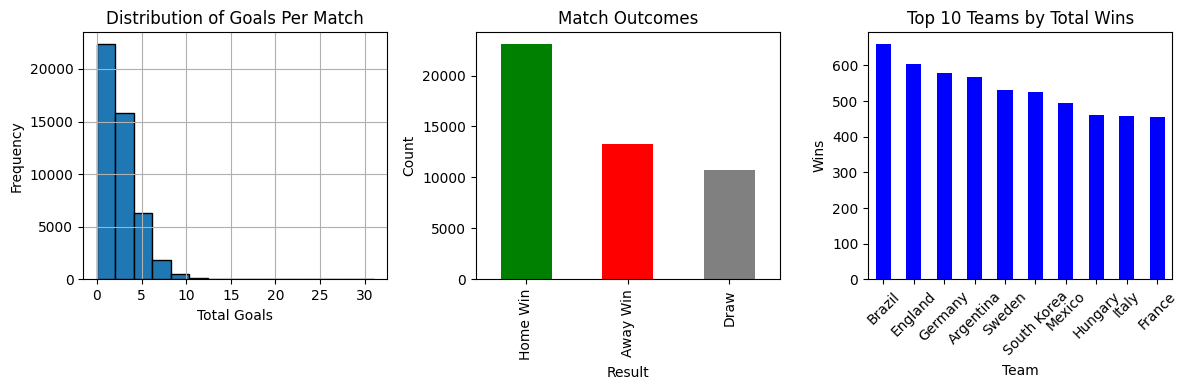

In [2]:
# Football Analysis - Assignment 1
# Kaggle Dataset: International Football Results (1872-2024)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the CSV
df = pd.read_csv("results.csv")  # Make sure results.csv is in the same folder
df.head()

#  BASIC EXPLORATION

# Question 1: How many matches are in the dataset?
print(f"Total matches: {df.shape[0]}")

# Question 2: What is the earliest and latest year?
df['date'] = pd.to_datetime(df['date'])
print(f"Earliest year: {df['date'].dt.year.min()}")
print(f"Latest year: {df['date'].dt.year.max()}")

# Question 3: How many unique countries are there?
home_teams = set(df['home_team'].unique())
away_teams = set(df['away_team'].unique())
all_teams = home_teams.union(away_teams)
print(f"Unique countries: {len(all_teams)}")

# Question 4: Which team appears most frequently as home team?
most_home_team = df['home_team'].value_counts().head(1)
print(f"Most frequent home team: {most_home_team}")

#  GOALS ANALYSIS 

# Create total goals column
df["total_goals"] = df["home_score"] + df["away_score"]

# Question 5: Average number of goals per match
print(f"Average goals per match: {df['total_goals'].mean():.2f}")

# Question 6: Highest scoring match
max_goals = df['total_goals'].max()
highest_scoring = df[df['total_goals'] == max_goals]
print(f"Highest score: {max_goals} goals")
print(highest_scoring[['date', 'home_team', 'away_team', 'home_score', 'away_score']])

# Question 7: Are more goals scored at home or away?
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()
print(f"Total home goals: {total_home_goals}")
print(f"Total away goals: {total_away_goals}")
print(f"Home goals are {(total_home_goals/total_away_goals - 1)*100:.1f}% higher")

# Question 8: Most common total goals value
most_common_goals = df['total_goals'].mode()[0]
print(f"Most common total goals: {most_common_goals}")

#  MATCH RESULTS 

# Create match outcome function
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)

# Question 9: Percentage of home wins
home_win_pct = (df['result'] == 'Home Win').mean() * 100
print(f"Home win percentage: {home_win_pct:.1f}%")

# Question 10: Does home advantage exist?
print(f"Home wins: {home_win_pct:.1f}%")
print(f"Away wins: {(df['result'] == 'Away Win').mean() * 100:.1f}%")
print(f"Draws: {(df['result'] == 'Draw').mean() * 100:.1f}%")
print("CONCLUSION: Yes, home advantage exists because home wins are significantly higher than away wins.")

# Question 11: Which country has the most wins historically?
home_wins = df[df['result'] == 'Home Win']['home_team'].value_counts()
away_wins = df[df['result'] == 'Away Win']['away_team'].value_counts()
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)
print(f"Country with most wins: {total_wins.head(1)}")

#  VISUALIZATION 

# Histogram of goals
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df["total_goals"].hist(bins=15, edgecolor='black')
plt.title("Distribution of Goals Per Match")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")

# Bar chart of match outcomes
plt.subplot(1, 3, 2)
df['result'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title("Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Count")

# Top 10 teams by total wins
plt.subplot(1, 3, 3)
total_wins.head(10).plot(kind='bar', color='blue')
plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()